In [1]:
import xarray as xr
import fsspec
import zarr
import dask.array as da
import numpy as np
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from datetime import datetime, timedelta
from metpy.calc import lat_lon_grid_deltas, vorticity, smooth_gaussian
from metpy.units import units
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cosine
from scipy.spatial import cKDTree 
from collections import deque
from sklearn.metrics.pairwise import cosine_similarity
from scipy import ndimage as ndi
from scipy.ndimage import maximum_filter
from skimage.morphology import skeletonize
from skimage.morphology import medial_axis

In [4]:
allLevelsFile = '../data/sandy2012-windUV_all_levels_from_250_to_850-rechunked.zarr'
subsetLevelsFile = '../data/sandy2012-windUV_250_500_850.zarr'
sandyCoordsFile = "../data/sandy2012-coords.csv"
gphFile = "../data/allLevelsGPH.nc"

allLevelsDs = xr.open_zarr(allLevelsFile, consolidated=False)
subsetLevelsDs = xr.open_zarr(subsetLevelsFile, consolidated=False)
sandyCoords = pd.read_csv(sandyCoordsFile)
gphDs = xr.open_dataset(gphFile)


In [7]:
sandyCoords["datetime"] = pd.to_datetime(sandyCoords["datetime"])
sandyCoords = sandyCoords.sort_values("datetime").reset_index(drop=True)

sandyCoords["lat"] = sandyCoords["lat"].astype(float)
sandyCoords["lon"] = sandyCoords["lon"].astype(float)
sandyCoords.head()


,datetime,lat,lon
0,2012-10-22 00:00:00,13.9,-77.8
1,2012-10-22 06:00:00,13.5,-78.2
2,2012-10-22 12:00:00,13.1,-78.6
3,2012-10-22 18:00:00,12.7,-78.7
4,2012-10-23 00:00:00,12.6,-78.4


In [6]:
gphDs

<xarray.Dataset> Size: 91GB
Dimensions:  (time: 1464, plev: 15, lat: 721, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 12kB 2012-10-01 ... 2012-11-30T23:00:00
  * plev     (plev) float64 120B 2.5e+04 3e+04 3.5e+04 ... 8.25e+04 8.5e+04
  * lat      (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Data variables:
    z        (time, plev, lat, lon) float32 91GB ...
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Fri Jan 30 12:15:44 2026: cdo -f nc4 -z zip_4 copy /home/dm...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

In [21]:
def get_gph_at_level_time(gphDs, level_hpa, time):
    """
    Select geopotential height (or geopotential) + lats/lons from gphDs at a given pressure level + time.

    Your gphDs schema:
      - variable: z (time, plev, lat, lon)
      - plev is in Pa (e.g. 2.5e4 = 250 hPa)
      - lat goes 90 -> -90 (descending)
      - lon goes 0..360 (0.25 deg)

    Output:
      z2d: (nlat, nlon)
      lats: increasing (-90 -> 90)
      lons: in [-180, 180)
    """
    # Convert requested level in hPa to Pa to match plev coordinate
    level_pa = float(level_hpa) * 100.0

    sel = gphDs.sel(time=np.datetime64(time), plev=level_pa, method="nearest")

    z2d = sel["z"].values
    lats = sel["lat"].values
    lons = sel["lon"].values

    # ---- Latitude: ensure increasing (-90 -> 90) ----
    if len(lats) > 1 and lats[0] > lats[-1]:
        lats = lats[::-1]
        z2d = z2d[::-1, :]

    # ---- Longitude: ensure [-180, 180) instead of [0, 360) ----
    if len(lons) > 0 and np.nanmax(lons) > 180:
        lons_wrapped = ((lons + 180) % 360) - 180
        order = np.argsort(lons_wrapped)

        lons = lons_wrapped[order]
        z2d = z2d[:, order]
        
    z_m = z2d / 9.80665

    return z_m, lats, lons

z, lats_gph, lons_gph = get_gph_at_level_time(
    gphDs,
    level_hpa=250,
    time="2012-10-29T00:00:00",
)
z

array([[9320.926 , 9320.926 , 9320.926 , ..., 9320.926 , 9320.926 ,
        9320.926 ],
       [9319.244 , 9319.192 , 9319.192 , ..., 9319.244 , 9319.244 ,
        9319.244 ],
       [9317.51  , 9317.51  , 9317.51  , ..., 9317.51  , 9317.51  ,
        9317.51  ],
       ...,
       [9638.364 , 9638.364 , 9638.364 , ..., 9638.415 , 9638.415 ,
        9638.415 ],
       [9638.109 , 9638.109 , 9638.109 , ..., 9638.16  , 9638.16  ,
        9638.16  ],
       [9638.3125, 9638.3125, 9638.3125, ..., 9638.3125, 9638.3125,
        9638.3125]], shape=(721, 1440), dtype=float32)

In [13]:
def interp_storm_latlon(storm_df, time):
    t = pd.to_datetime(time)

    dt = storm_df["datetime"].values

    if t.to_datetime64() < dt[0] or t.to_datetime64() > dt[-1]:
        return None

    exact = storm_df.loc[storm_df["datetime"] == t]
    if len(exact) > 0:
        return float(exact["lat"].iloc[0]), float(exact["lon"].iloc[0])

    i = np.searchsorted(dt, t.to_datetime64(), side="right")
    i0, i1 = i - 1, i

    t0 = storm_df["datetime"].iloc[i0]
    t1 = storm_df["datetime"].iloc[i1]

    frac = (t - t0) / (t1 - t0)

    lat0, lat1 = storm_df["lat"].iloc[i0], storm_df["lat"].iloc[i1]
    lon0, lon1 = storm_df["lon"].iloc[i0], storm_df["lon"].iloc[i1]

    lat = float(lat0 + frac * (lat1 - lat0))
    lon = float(lon0 + frac * (lon1 - lon0))

    return lat, lon

(<Figure size 1200x600 with 2 Axes>,
 <GeoAxes: title={'center': 'GPH @ 250hPa — 2012-10-29 00Z'}>)

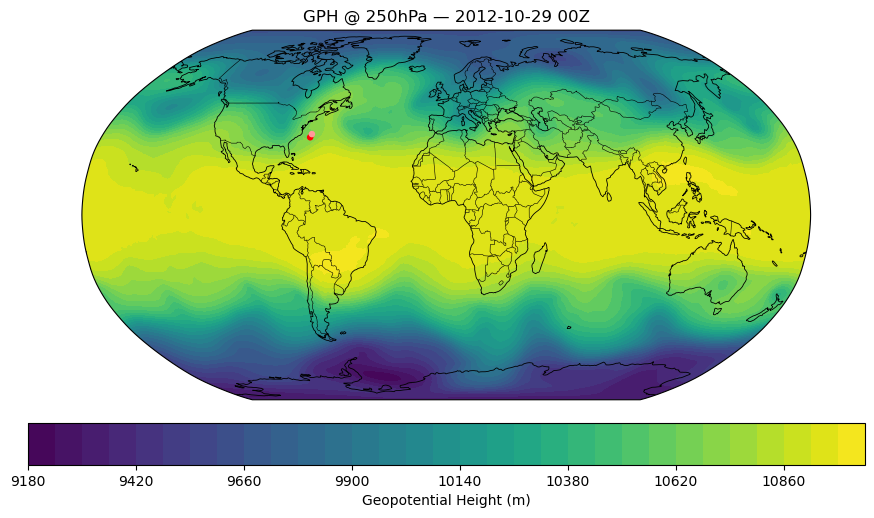

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

def plot_gph_world(
    z_m,
    lats,
    lons,
    *,
    time=None,
    ax=None,
    title: str | None = None,
    storm_df: pd.DataFrame | None = None,
    show_storm_dot: bool = True,
    storm_dot_size: float = 22,
    levels=31,
):
    """
    Plot geopotential height (meters) on a global map with Cartopy + optional storm dots.
    Assumes interp_storm_latlon(storm_df, time) is defined elsewhere.

    Inputs:
      z_m: 2D array (nlat, nlon)
      lats: 1D array (nlat)
      lons: 1D array (nlon)
    """
    z = np.asarray(z_m)
    lats = np.asarray(lats)
    lons = np.asarray(lons)

    # Ensure lats increasing
    if len(lats) > 1 and lats[0] > lats[-1]:
        lats = lats[::-1]
        z = z[::-1, :]

    # Wrap 0..360 -> -180..180 and reorder
    if len(lons) > 0 and np.nanmax(lons) > 180:
        lons_wrapped = ((lons + 180) % 360) - 180
        order = np.argsort(lons_wrapped)
        lons = lons_wrapped[order]
        z = z[:, order]

    Lon, Lat = np.meshgrid(lons, lats)

    proj = ccrs.Robinson()
    if ax is None:
        fig = plt.figure(figsize=(12, 6))
        ax = plt.axes(projection=proj)
    else:
        fig = None

    ax.set_global()

    ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.6, zorder=2)
    ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.4, zorder=2)

    cf = ax.contourf(
        Lon, Lat, z,
        levels=levels,
        transform=ccrs.PlateCarree(),
        zorder=0
    )
    cbar = plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05, shrink=0.9)
    cbar.set_label("Geopotential Height (m)")

    # ---- storm dots (needs time) ----
    if show_storm_dot and storm_df is not None and time is not None:
        pt = interp_storm_latlon(storm_df, time)
        if pt is not None:
            lat_pt, lon_pt = pt
            ax.scatter(
                [lon_pt], [lat_pt],
                transform=ccrs.PlateCarree(),
                s=storm_dot_size,
                c="red",
                edgecolors="none",
                zorder=10,
            )

            t_next = pd.to_datetime(time) + pd.Timedelta(hours=6)
            pt2 = interp_storm_latlon(storm_df, t_next)
            if pt2 is not None:
                lat2, lon2 = pt2
                ax.scatter(
                    [lon2], [lat2],
                    transform=ccrs.PlateCarree(),
                    s=storm_dot_size,
                    c="#ff9999",
                    edgecolors="none",
                    zorder=10,
                )
                ax.plot(
                    [lon_pt, lon2],
                    [lat_pt, lat2],
                    transform=ccrs.PlateCarree(),
                    color="red",
                    linewidth=1.5,
                    zorder=9,
                )

    if title is not None:
        ax.set_title(title)

    return fig, ax

plot_gph_world(
    z,
    lats_gph,
    lons_gph,
    title=f"GPH @ 250hPa — 2012-10-29 00Z",
    storm_df=sandyCoords,
    time="2012-10-29T00:00:00"
)

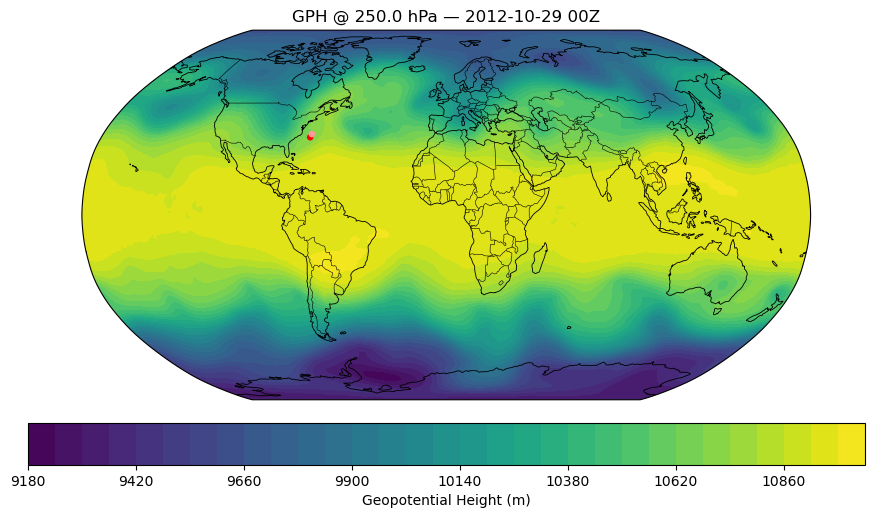

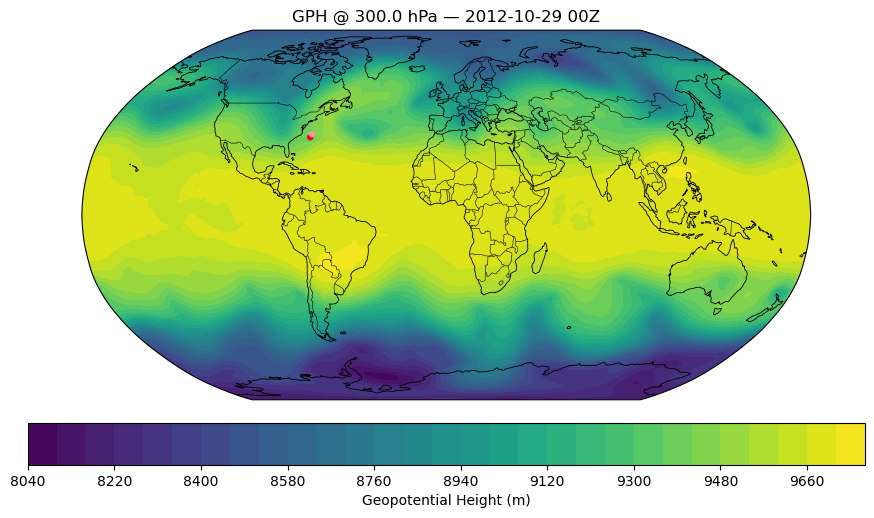

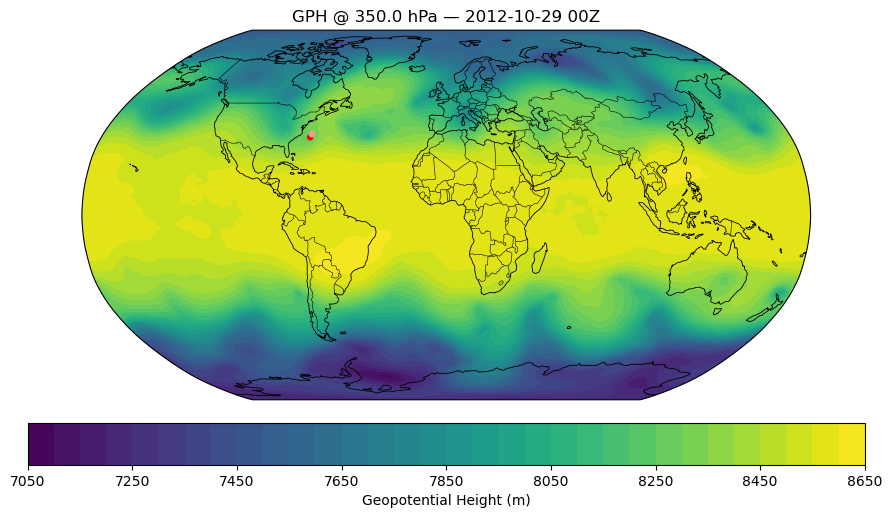

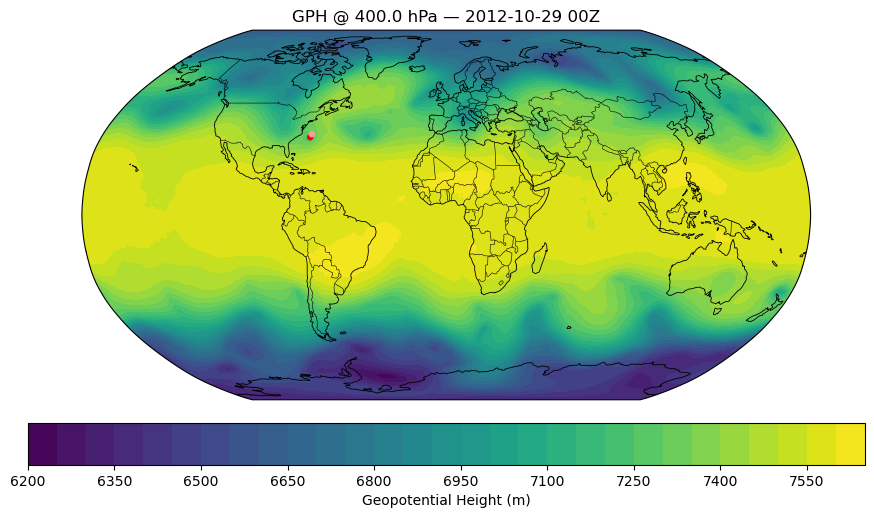

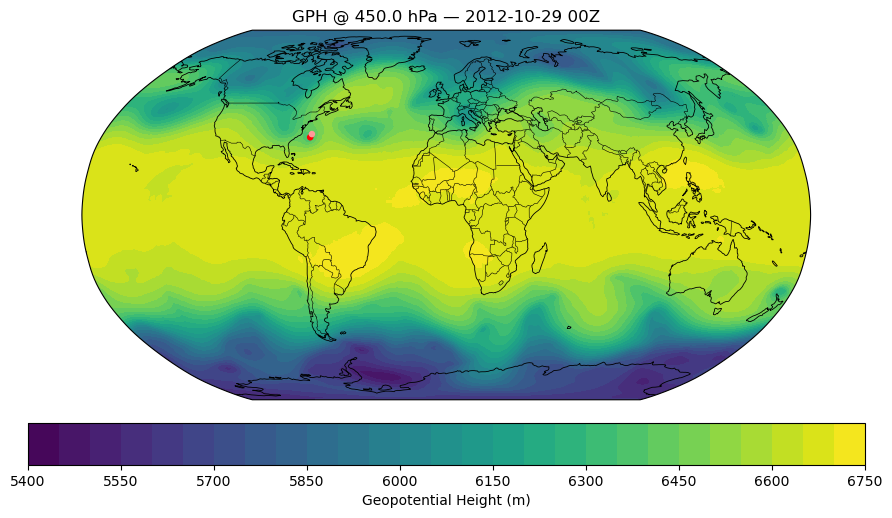

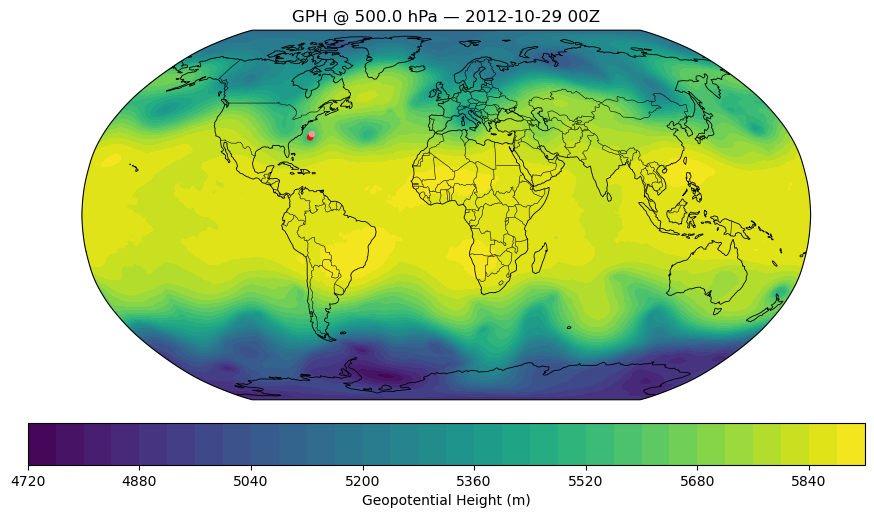

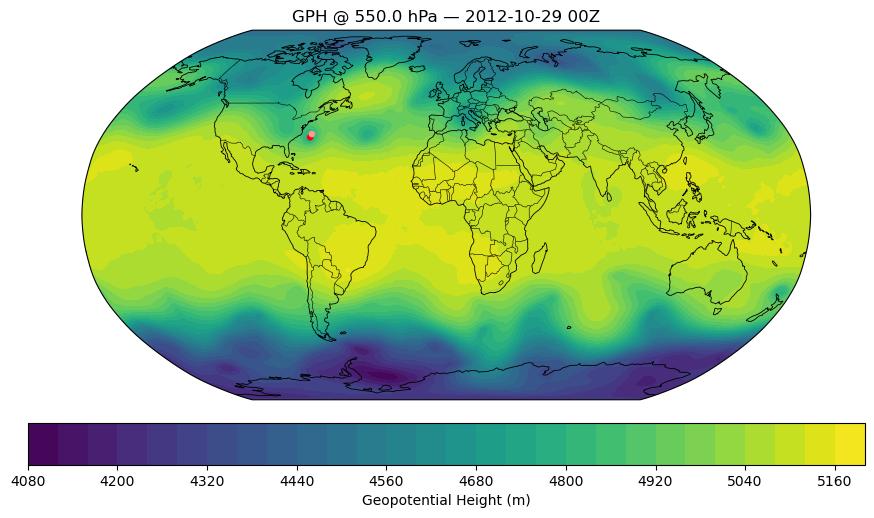

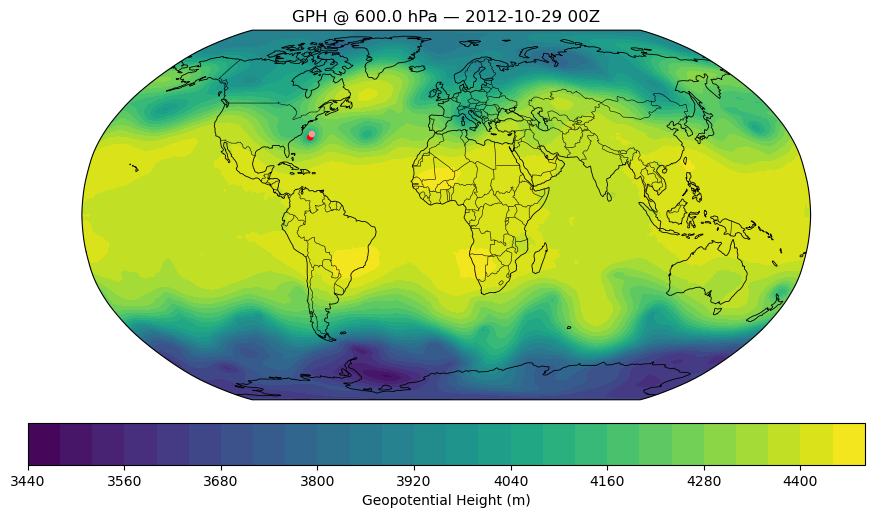

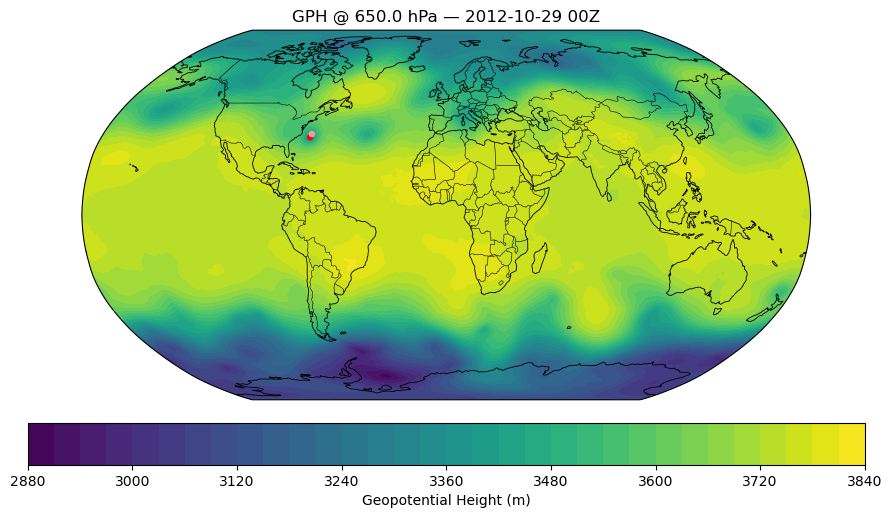

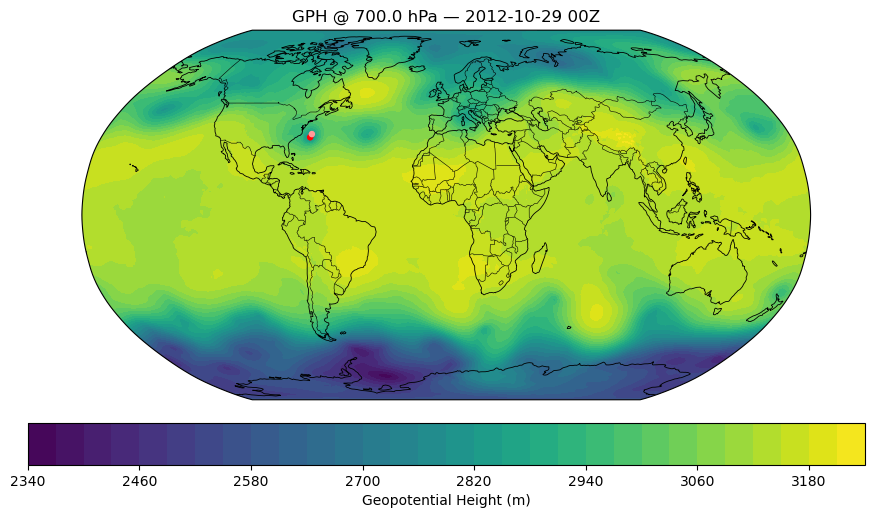

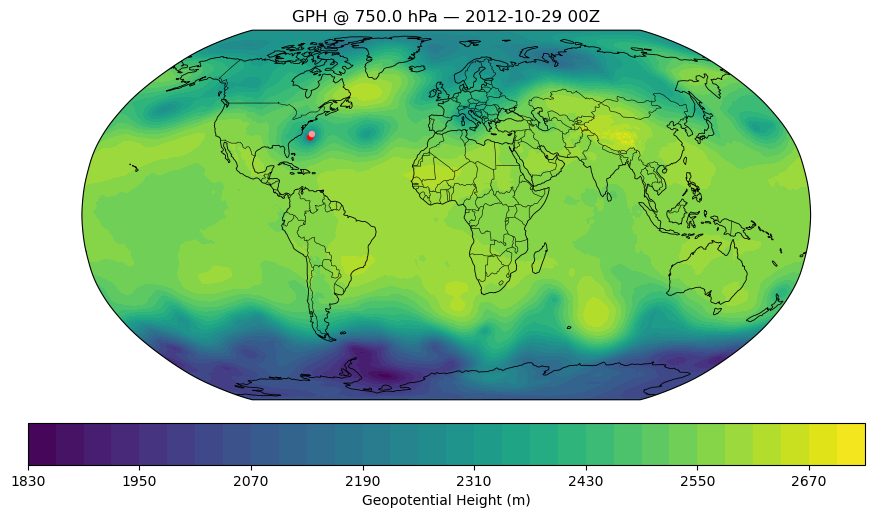

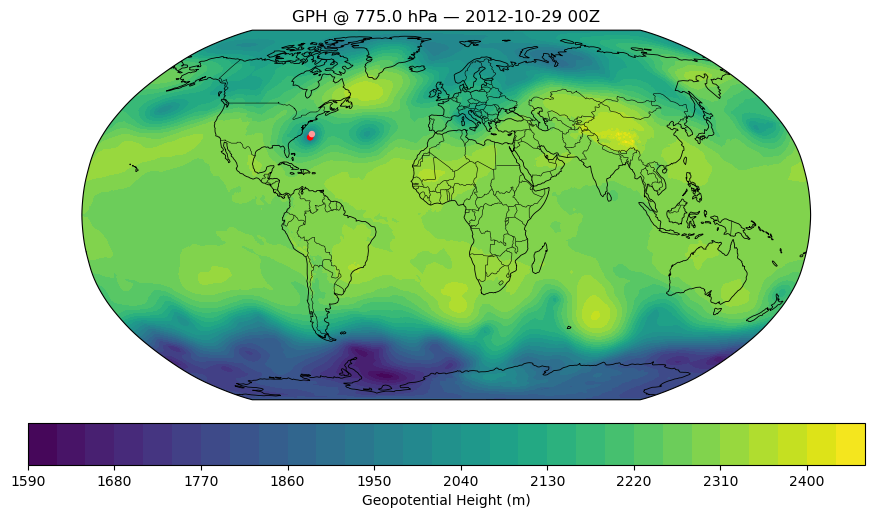

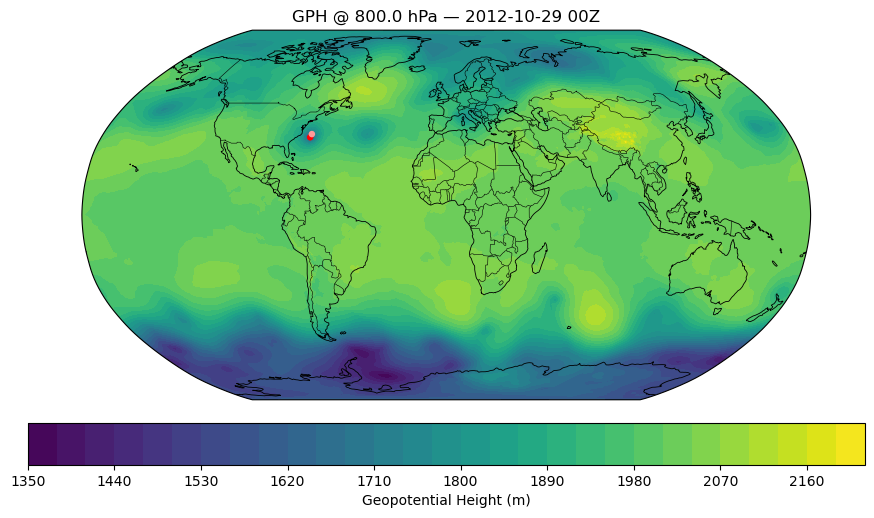

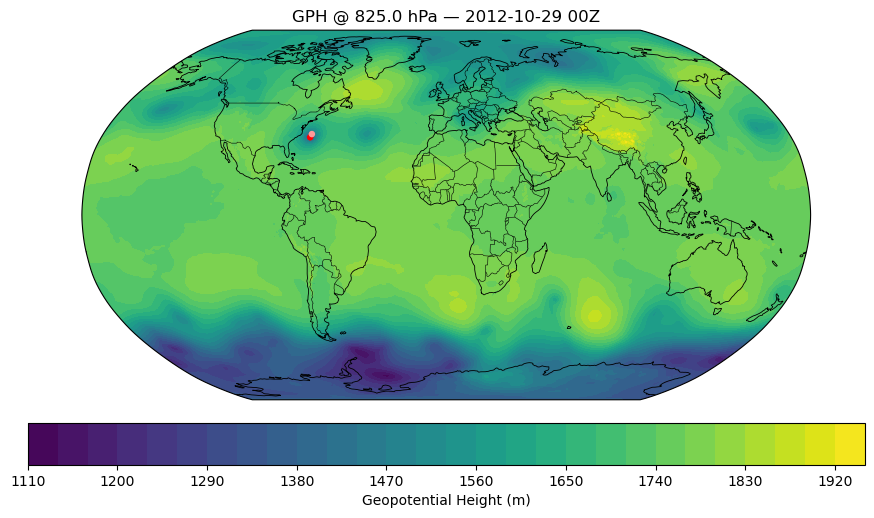

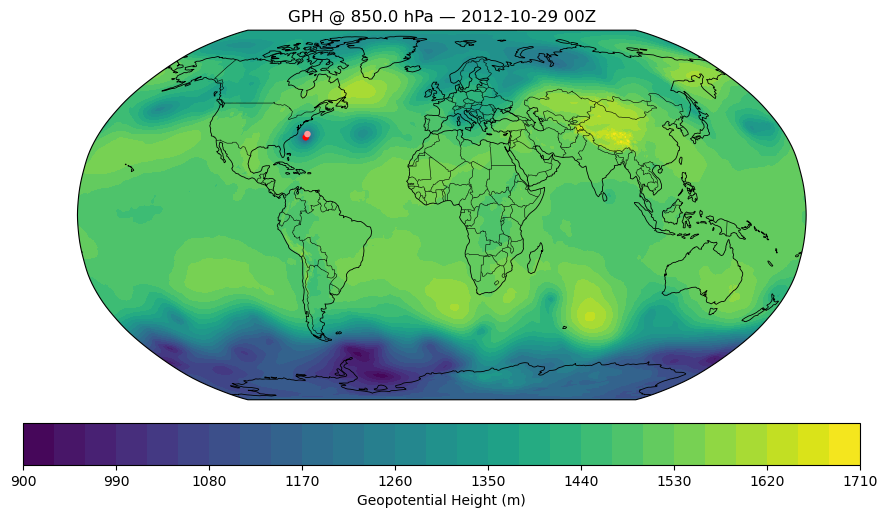

In [24]:
for lev in gphDs.plev.values:
    level = lev / 100
    z, lats_gph, lons_gph = get_gph_at_level_time(
        gphDs,
        level_hpa=level,
        time="2012-10-29T00:00:00",
    )
    plot_gph_world(
        z,
        lats_gph,
        lons_gph,
        title=f"GPH @ {level} hPa — 2012-10-29 00Z",
        storm_df=sandyCoords,
        time="2012-10-29T00:00:00"
    )
    plt.show()

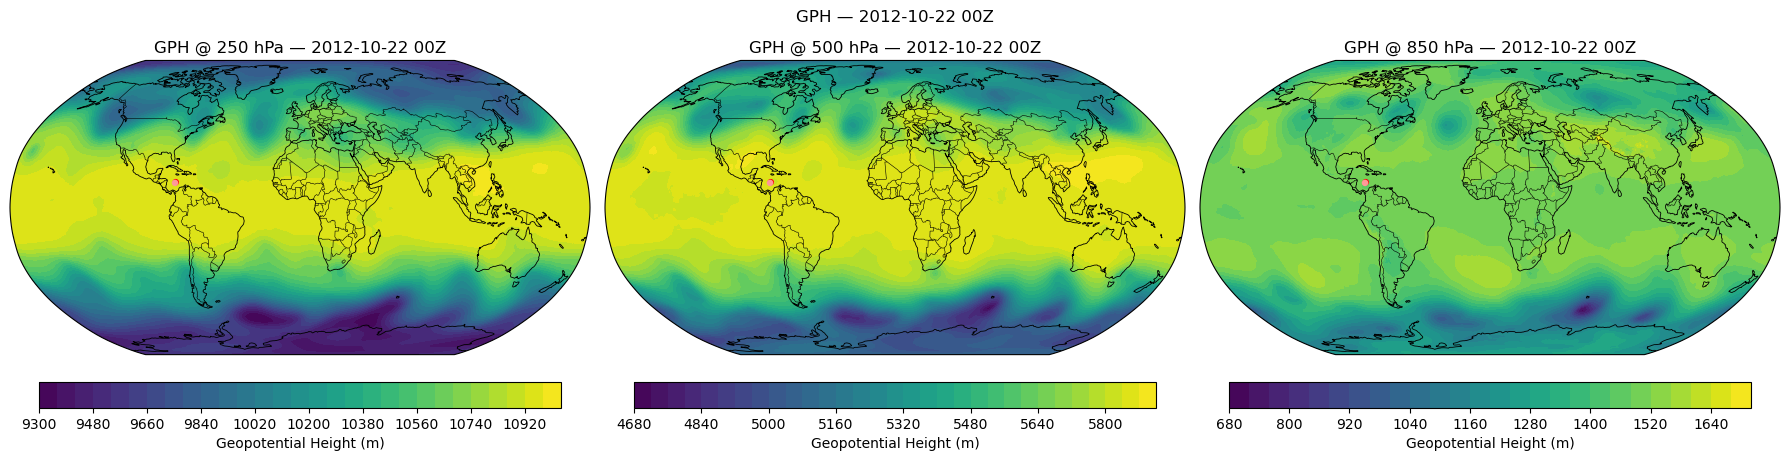

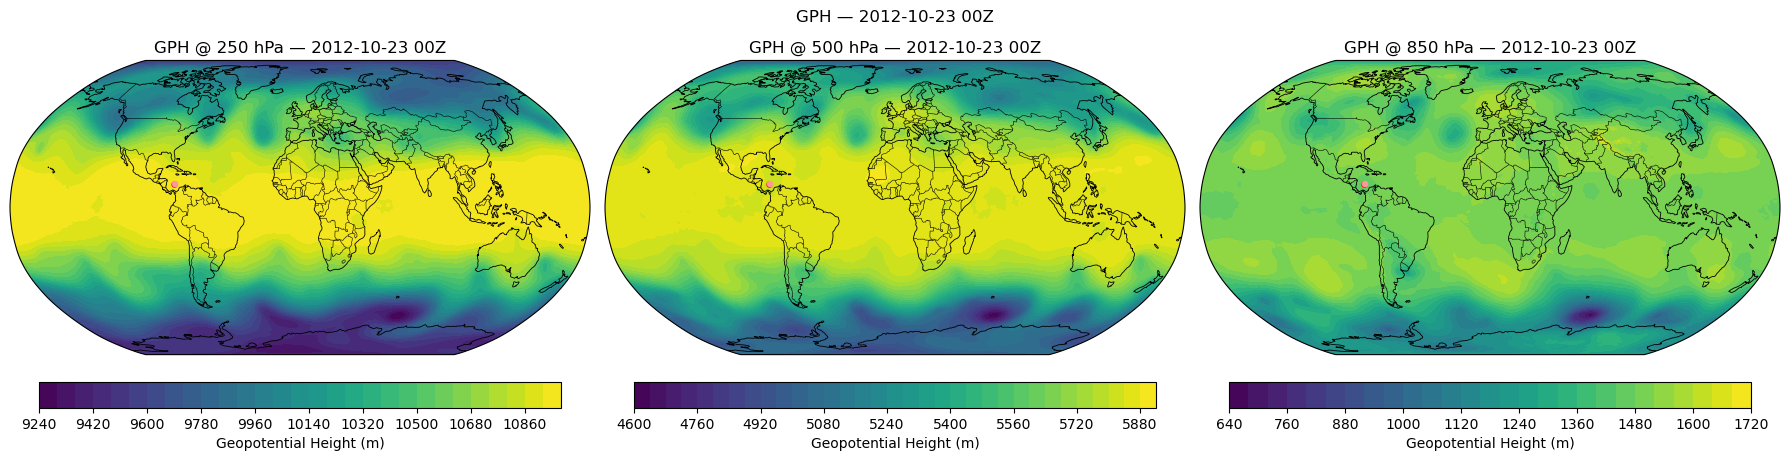

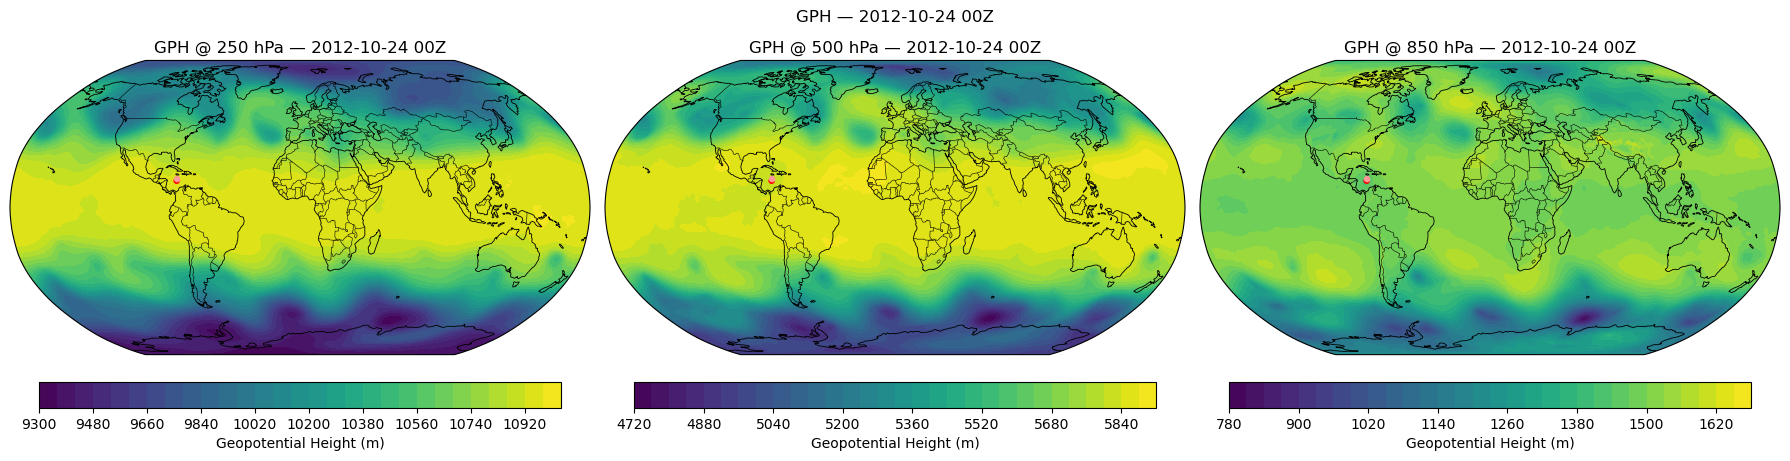

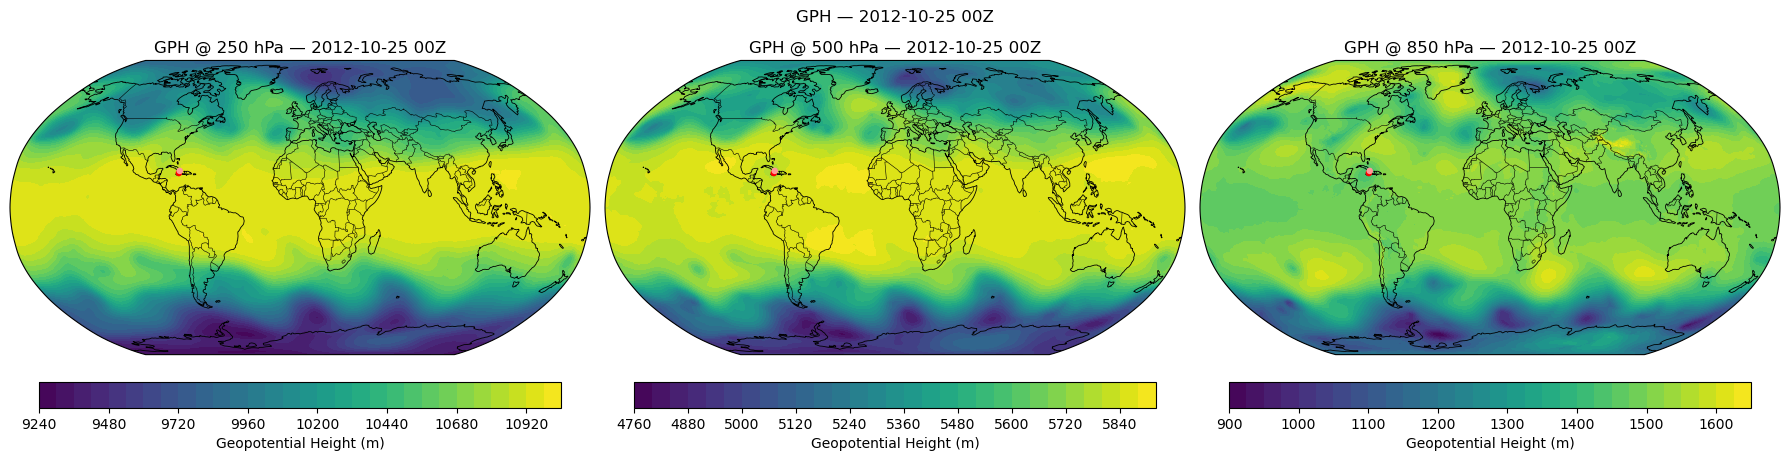

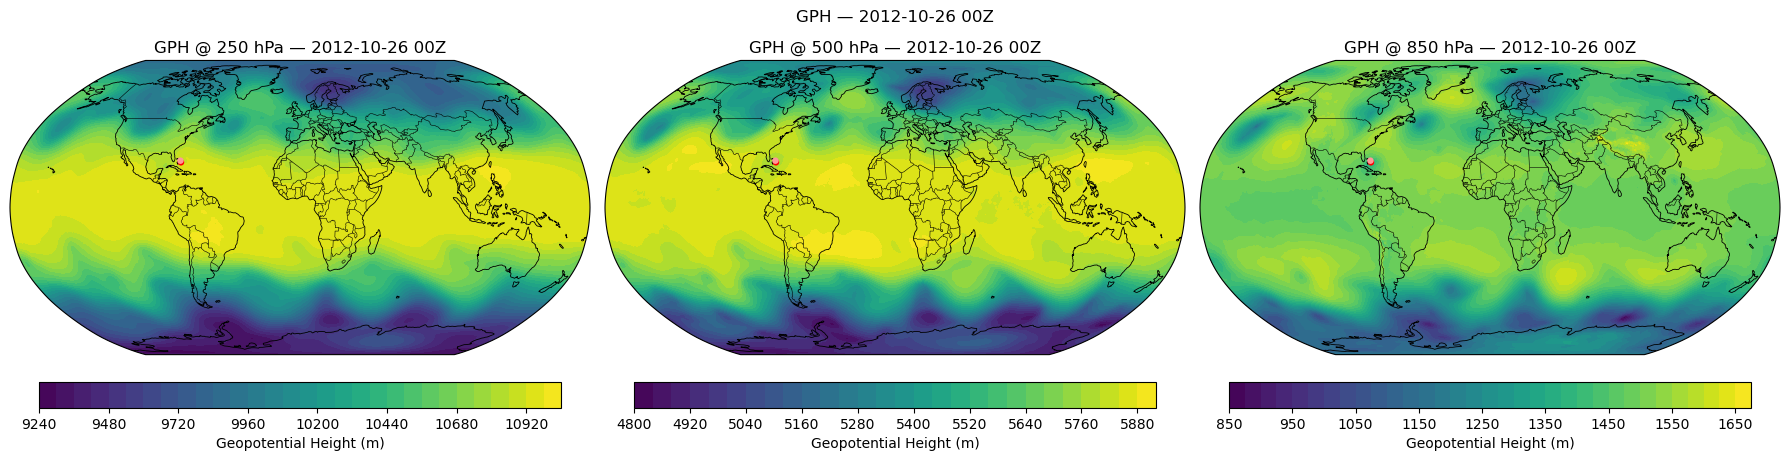

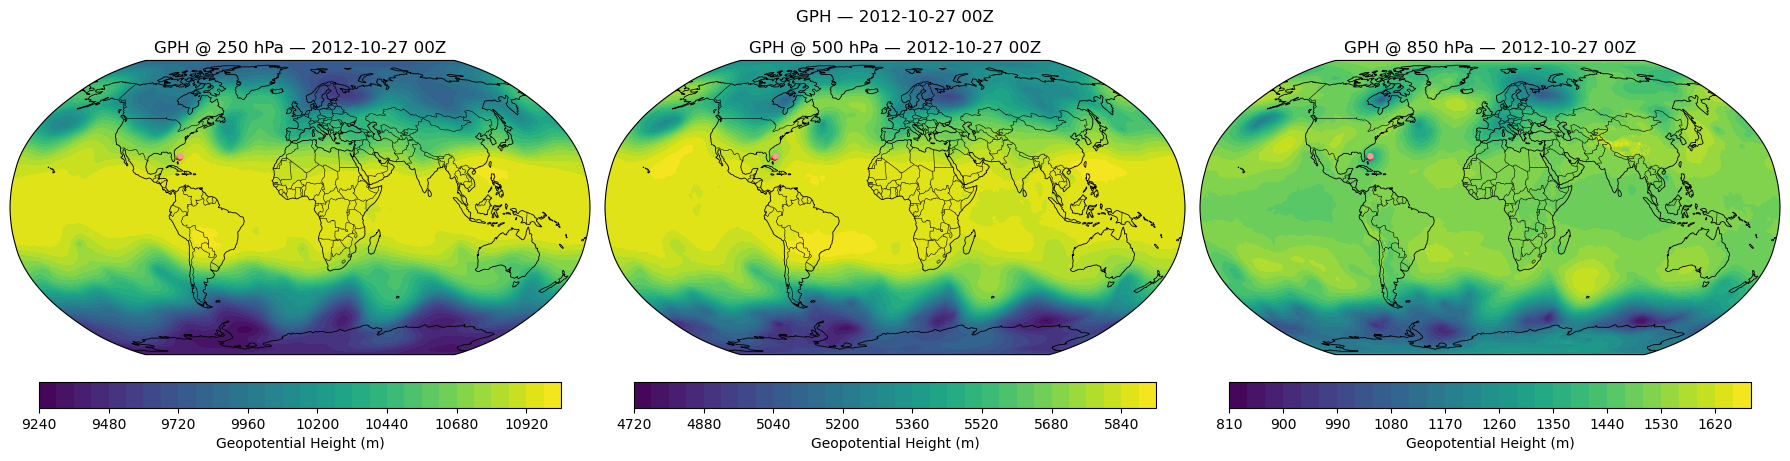

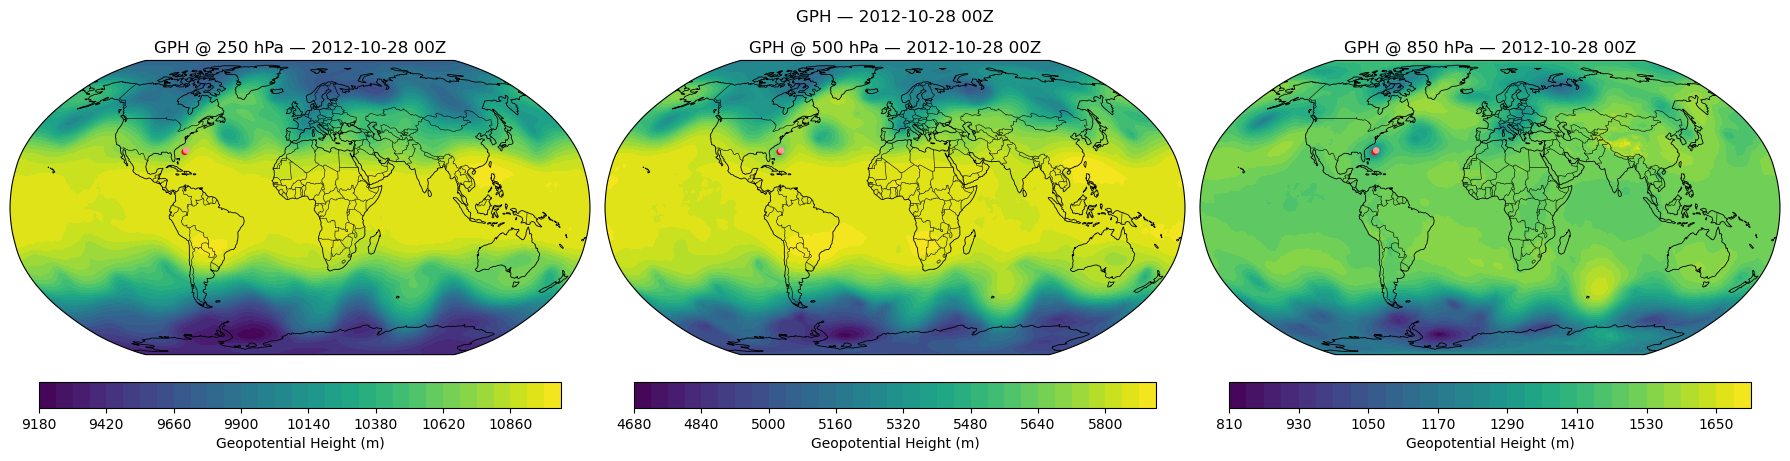

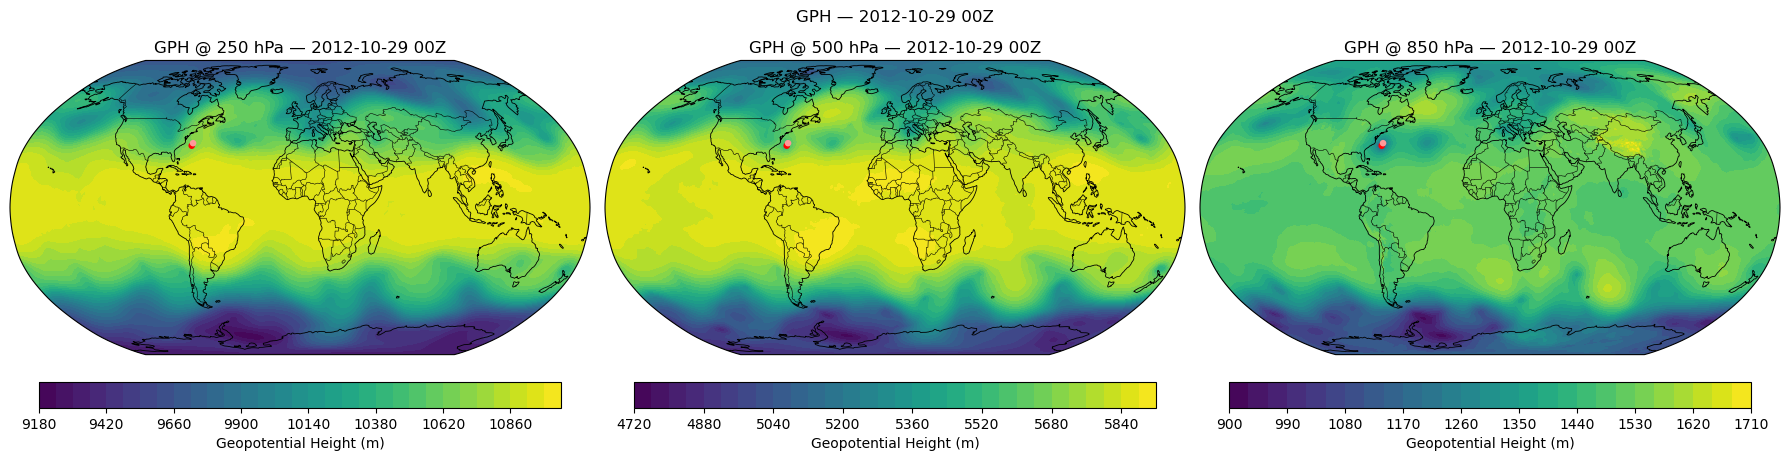

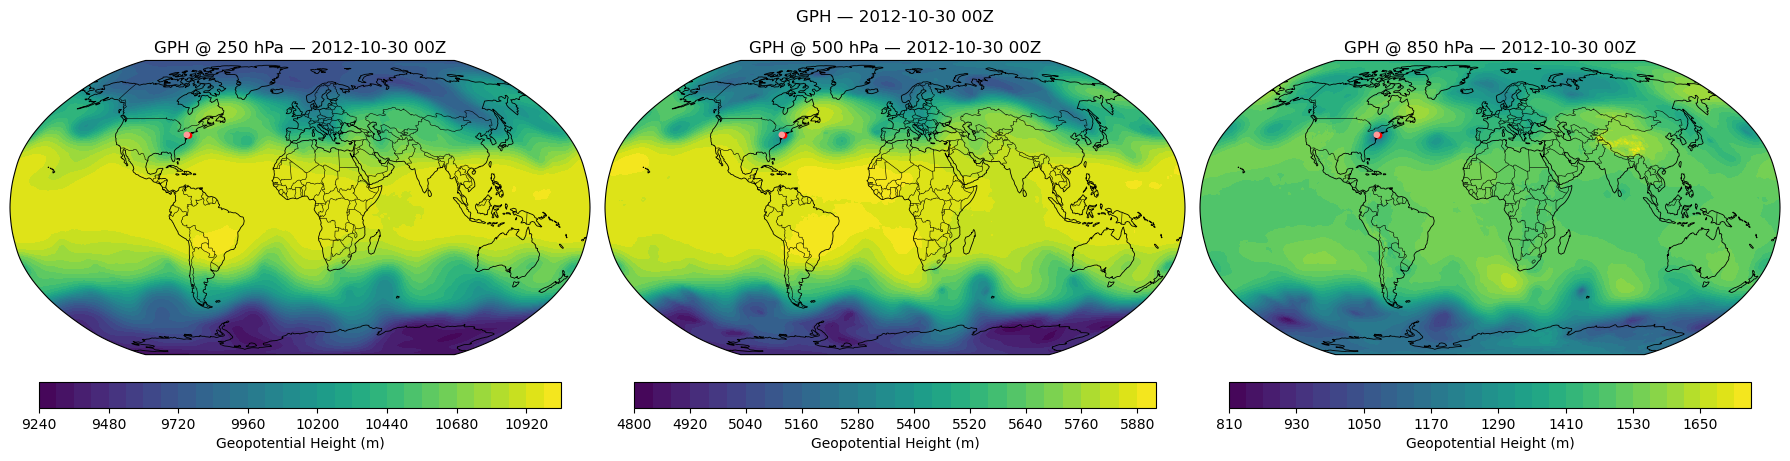

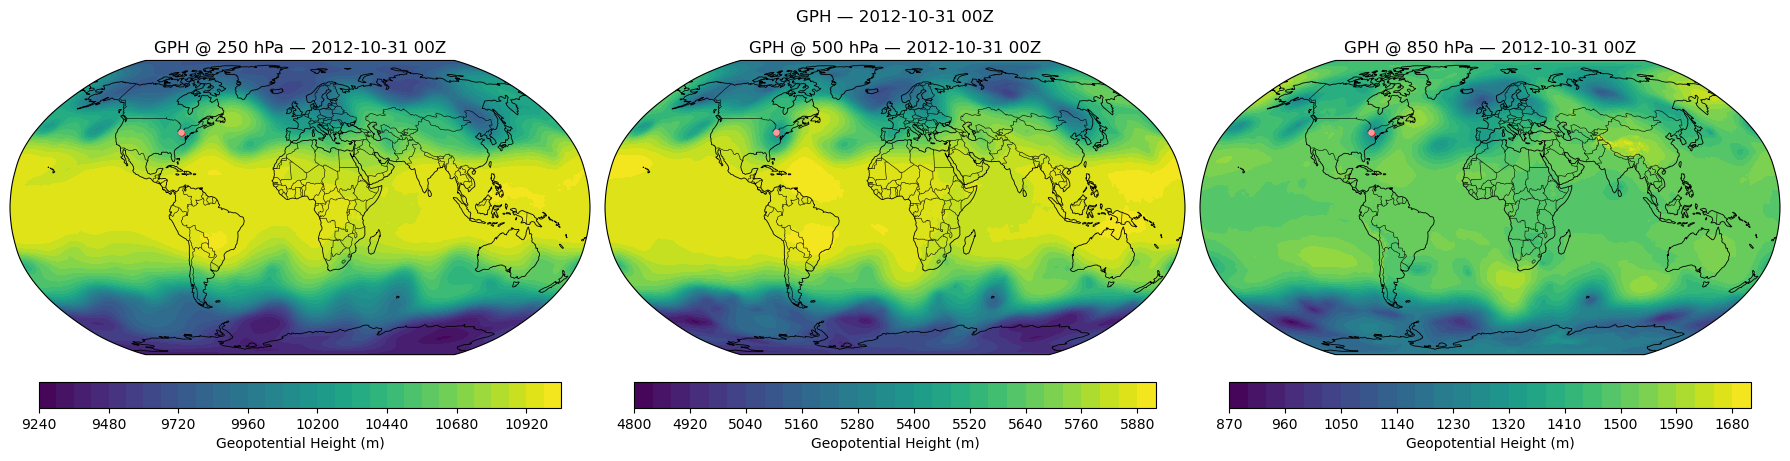

In [31]:
start = "2012-10-22T00:00:00"
end   = "2012-10-31T12:00:00"

times = pd.date_range(start=start, end=end, freq="24h")
levels_hpa = [250, 500, 850]

for t in times:
    fig, axs = plt.subplots(
        1, 3,
        figsize=(18, 6),
        subplot_kw={"projection": ccrs.Robinson()}
    )

    for ax, level in zip(axs, levels_hpa):
        z, lats_gph, lons_gph = get_gph_at_level_time(
            gphDs,
            level_hpa=level,
            time=t,
        )
        plot_gph_world(
            z,
            lats_gph,
            lons_gph,
            ax=ax,
            title=f"GPH @ {level} hPa — {pd.to_datetime(t).strftime('%Y-%m-%d %HZ')}",
            storm_df=sandyCoords,
            time=t,
        )

    fig.suptitle(pd.to_datetime(t).strftime("GPH — %Y-%m-%d %HZ"), y=0.78)
    plt.tight_layout()
    plt.show()


In [32]:
[i for i in gphDs.plev.values]

[np.float64(25000.0),
 np.float64(30000.0),
 np.float64(35000.0),
 np.float64(40000.0),
 np.float64(45000.0),
 np.float64(50000.0),
 np.float64(55000.0),
 np.float64(60000.0),
 np.float64(65000.0),
 np.float64(70000.0),
 np.float64(75000.0),
 np.float64(77500.0),
 np.float64(80000.0),
 np.float64(82500.0),
 np.float64(85000.0)]